In [1]:

# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import os
import joblib
import logging

# Machine Learning / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# XGBoost
import xgboost as xgb

# Suppress Prophet warnings
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)



In [2]:

def evaluate_model(actual, predicted):
    """Compute MAE and RMSE."""
    mae = mean_absolute_error(actual, predicted)
    rmse = sqrt(mean_squared_error(actual, predicted))
    return {"MAE": mae, "RMSE": rmse}

def train_test_split_ts(df, split_ratio=0.8):
    """Split time series data (chronologically)."""
    split = int(len(df) * split_ratio)
    train = df.iloc[:split]
    test = df.iloc[split:]
    return train, test



In [3]:

df = pd.read_csv("AirQuality_daily_clean.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)
df = df.asfreq('D').fillna(method='ffill')   
df.head()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10,1.966667,1316.500000,86.500000,8.450000,912.333333,132.000000,1167.333333,108.833333,1545.500000,1096.000000,12.033333,54.900000,0.765633
2004-03-11,-6.187500,1244.166667,104.500000,7.979167,851.958333,130.041667,1277.250000,87.375000,1522.833333,885.250000,9.837500,64.075000,0.775767
2004-03-12,-14.095833,1281.666667,141.500000,12.129167,1008.291667,142.583333,1101.875000,89.916667,1627.291667,1084.375000,11.287500,51.095833,0.663104
2004-03-13,-5.750000,1330.666667,139.250000,10.916667,992.833333,168.416667,993.208333,105.583333,1595.791667,1245.916667,12.866667,51.533333,0.732296
2004-03-14,-5.966667,1361.125000,116.958333,9.637500,943.916667,132.166667,1001.291667,97.458333,1602.375000,1234.208333,16.012500,48.850000,0.849671


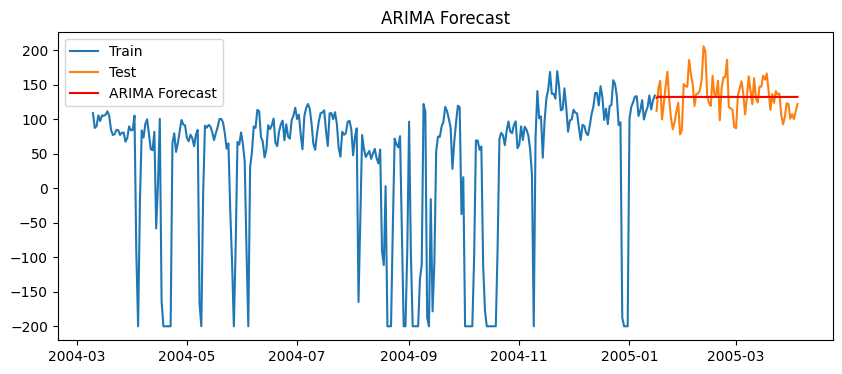

{'MAE': 21.50389624520488, 'RMSE': 26.579837343614102}


In [4]:

def arima_forecast(train, test, target_col):
    model = ARIMA(train[target_col], order=(1,1,1))
    res = model.fit()
    forecast = res.forecast(steps=len(test))
    eval_metrics = evaluate_model(test[target_col], forecast)
    
    plt.figure(figsize=(10,4))
    plt.plot(train[target_col], label='Train')
    plt.plot(test[target_col], label='Test')
    plt.plot(test.index, forecast, label='ARIMA Forecast', color='red')
    plt.legend()
    plt.title("ARIMA Forecast")
    plt.show()
    
    return res, forecast, eval_metrics

# Example run
target = 'NO2(GT)'
train, test = train_test_split_ts(df)
arima_model, arima_pred, arima_eval = arima_forecast(train, test, target)
print(arima_eval)


19:19:24 - cmdstanpy - INFO - Chain [1] start processing
19:19:24 - cmdstanpy - INFO - Chain [1] done processing


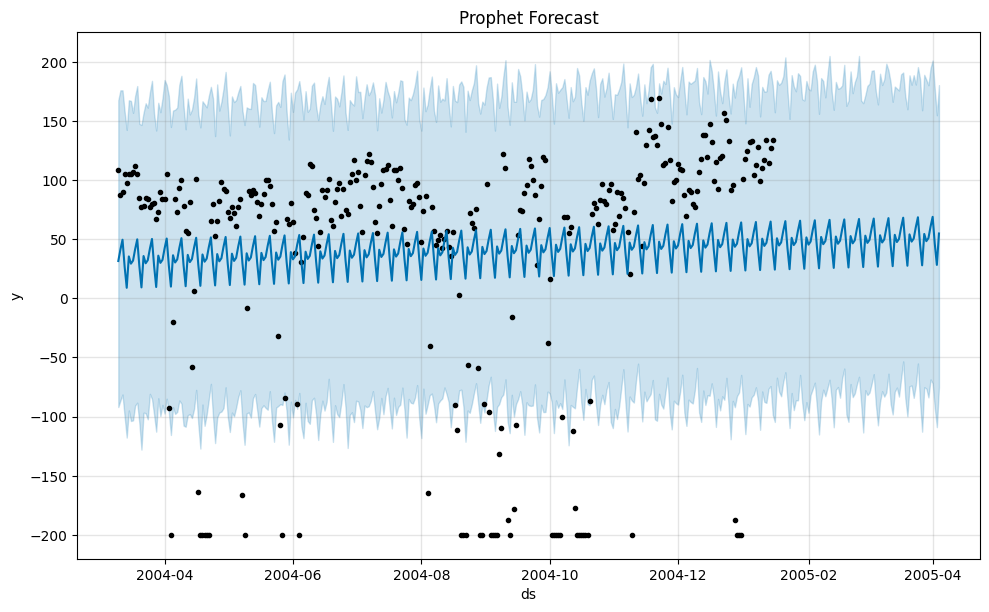

{'MAE': 83.74383805247194, 'RMSE': 87.37956271645605}


In [5]:

def prophet_forecast(train, test, target_col):
    prophet_df = train.reset_index()[['Datetime', target_col]].rename(columns={'Datetime':'ds', target_col:'y'})
    m = Prophet(daily_seasonality=True)
    m.fit(prophet_df)
    
    future = m.make_future_dataframe(periods=len(test), freq='D')
    forecast = m.predict(future)
    pred = forecast.set_index('ds')['yhat'][-len(test):]
    
    eval_metrics = evaluate_model(test[target_col], pred)
    
    m.plot(forecast)
    plt.title("Prophet Forecast")
    plt.show()
    
    return m, pred, eval_metrics

prophet_model, prophet_pred, prophet_eval = prophet_forecast(train, test, target)
print(prophet_eval)


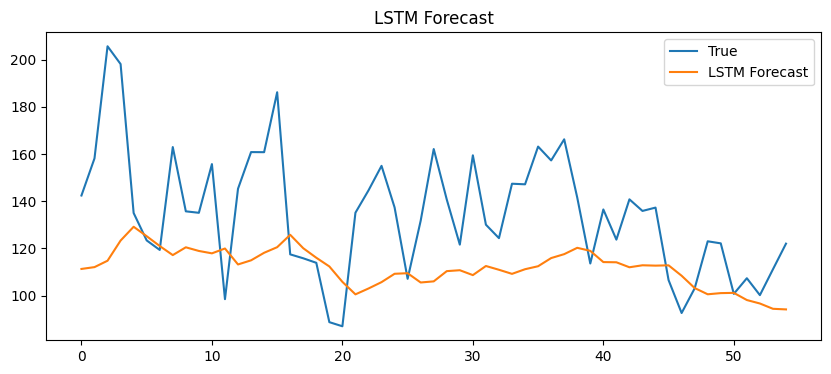

{'MAE': 26.683980213512076, 'RMSE': 33.2316352245679}


In [6]:
# --- Snippet 6: LSTM Forecast ---

def lstm_forecast(df, target_col, seq_length=24, epochs=10):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[[target_col]])

    train_size = int(len(scaled_data) * 0.8)
    train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(seq_length, len(data)):
            X.append(data[i-seq_length:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_data, seq_length)
    X_test, y_test = create_sequences(test_data, seq_length)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(seq_length,1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, validation_split=0.1, verbose=0)

    pred_scaled = model.predict(X_test)
    pred = scaler.inverse_transform(pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    eval_metrics = evaluate_model(y_true, pred)

    plt.figure(figsize=(10,4))
    plt.plot(y_true, label='True')
    plt.plot(pred, label='LSTM Forecast')
    plt.legend()
    plt.title("LSTM Forecast")
    plt.show()

    return model, pred, eval_metrics

lstm_model, lstm_pred, lstm_eval = lstm_forecast(df, target)
print(lstm_eval)


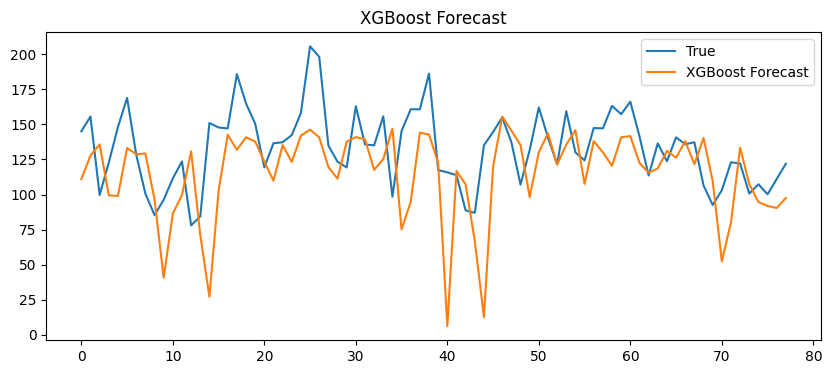

{'MAE': 27.101014365497814, 'RMSE': 36.73927692895627}


In [7]:

def xgboost_forecast(df, target_col, lags=[1,2,3]):
    for lag in lags:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    df_lag = df.dropna()

    X = df_lag[[f'lag_{lag}' for lag in lags]]
    y = df_lag[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05, max_depth=5)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    eval_metrics = evaluate_model(y_test, pred)

    plt.figure(figsize=(10,4))
    plt.plot(y_test.values, label='True')
    plt.plot(pred, label='XGBoost Forecast')
    plt.legend()
    plt.title("XGBoost Forecast")
    plt.show()

    return model, pred, eval_metrics

xgb_model, xgb_pred, xgb_eval = xgboost_forecast(df, target)
print(xgb_eval)


In [8]:

results = {
    "ARIMA": arima_eval,
    "Prophet": prophet_eval,
    "LSTM": lstm_eval,
    "XGBoost": xgb_eval
}

for model_name, metrics in results.items():
    print(f"{model_name:<10} | MAE={metrics['MAE']:.3f}, RMSE={metrics['RMSE']:.3f}")

best_model = min(results, key=lambda x: results[x]['MAE'])
print(f"\n Best model based on MAE: {best_model}")


ARIMA      | MAE=21.504, RMSE=26.580
Prophet    | MAE=83.744, RMSE=87.380
LSTM       | MAE=26.684, RMSE=33.232
XGBoost    | MAE=27.101, RMSE=36.739

 Best model based on MAE: ARIMA



📍 Training for: Global


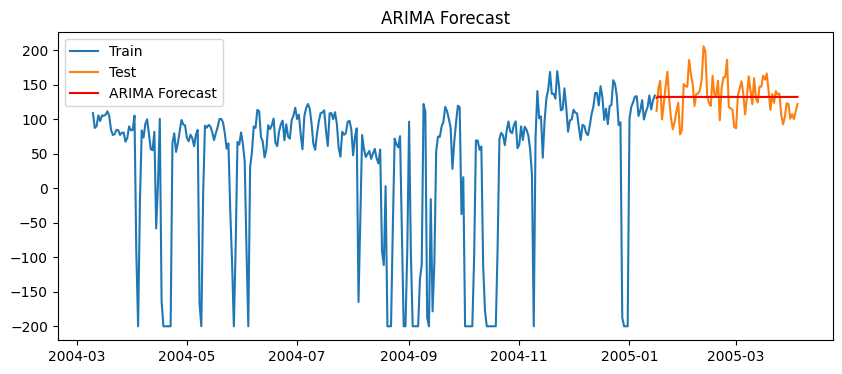

19:20:13 - cmdstanpy - INFO - Chain [1] start processing
19:20:13 - cmdstanpy - INFO - Chain [1] done processing


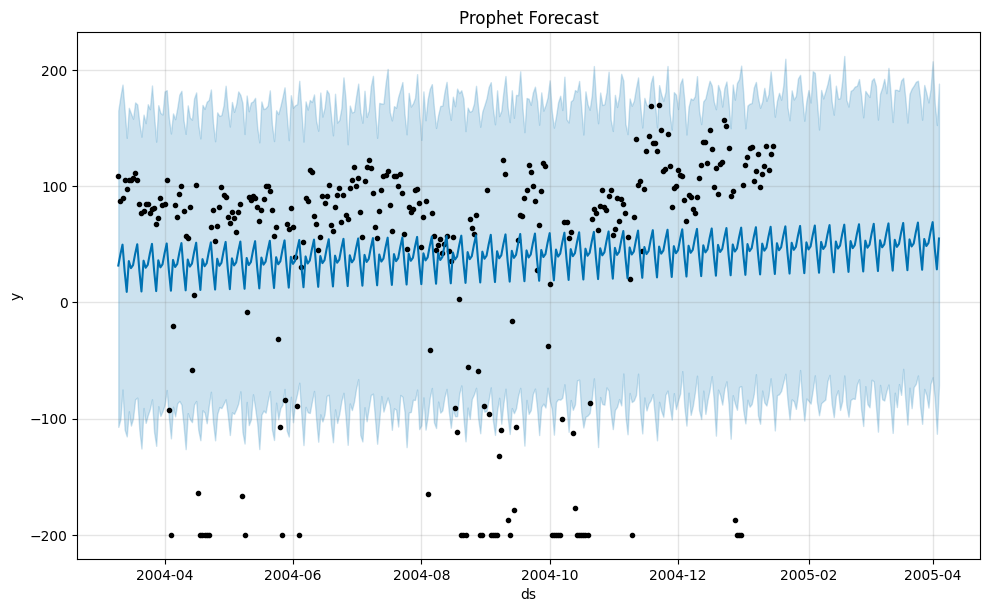

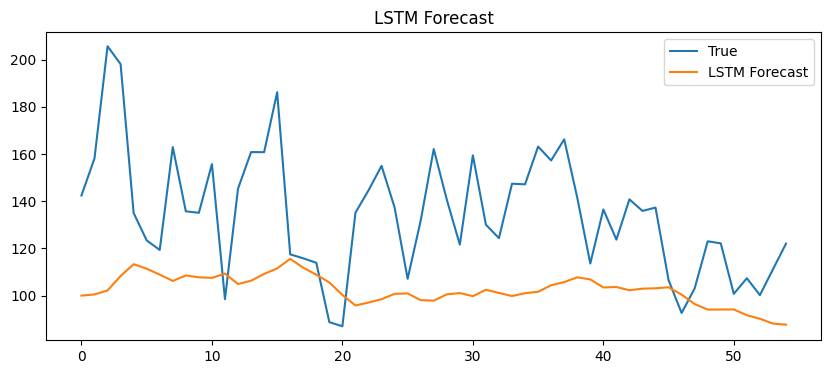

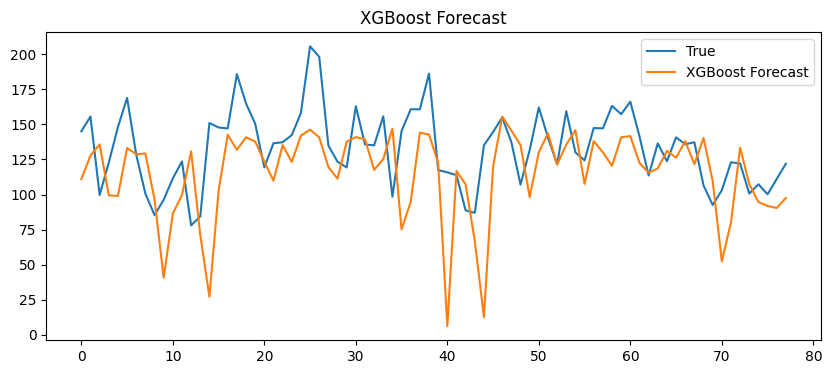


 Per-station training complete. Results saved to station_model_results.csv


In [9]:
# ---  Train per-station models ---

stations = df['Station'].unique() if 'Station' in df.columns else [None]
all_results = {}

for station in stations:
    print(f"\n📍 Training for: {station if station else 'Global'}")
    df_station = df[df['Station']==station] if station else df.copy()
    train, test = train_test_split_ts(df_station)

    arima_model, _, arima_eval = arima_forecast(train, test, target)
    prophet_model, _, prophet_eval = prophet_forecast(train, test, target)
    lstm_model, _, lstm_eval = lstm_forecast(df_station, target)
    xgb_model, _, xgb_eval = xgboost_forecast(df_station, target)

    results = {"ARIMA": arima_eval, "Prophet": prophet_eval, "LSTM": lstm_eval, "XGBoost": xgb_eval}
    all_results[station if station else 'Global'] = results

pd.DataFrame(all_results).to_csv("station_model_results.csv")
print("\n Per-station training complete. Results saved to station_model_results.csv")


In [10]:

# -------------------------------------------------
# Identify the best-performing model automatically
# -------------------------------------------------
summary = pd.DataFrame(results, index=['MAE','RMSE']).T
best_model_name = summary.sort_values(['MAE','RMSE']).index[0]
print(f"\n🏆 Best model based on MAE & RMSE: {best_model_name}")

# -------------------------------------------------
# Save the best-performing model for future use
# -------------------------------------------------
if best_model_name == 'ARIMA':
    joblib.dump(arima_model, "best_model_ARIMA.pkl")
    print("✅ Best model (ARIMA) saved as best_model_ARIMA.pkl")

elif best_model_name == 'Prophet':
    joblib.dump(prophet_model, "best_model_Prophet.pkl")
    print("✅ Best model (Prophet) saved as best_model_Prophet.pkl")

elif best_model_name == 'XGBoost':
    joblib.dump(xgb_model, "best_model_XGBoost.pkl")
    print("✅ Best model (XGBoost) saved as best_model_XGBoost.pkl")

elif best_model_name == 'LSTM':
    lstm_model.save("best_model_LSTM.h5")
    joblib.dump(scaler, "scaler_LSTM.pkl")
    print("✅ Best model (LSTM) saved as best_model_LSTM.h5 and scaler_LSTM.pkl")



🏆 Best model based on MAE & RMSE: ARIMA
✅ Best model (ARIMA) saved as best_model_ARIMA.pkl
